# Notebook 09: Sensitivity Analysis

**Dissertation: "Agentic AI for Sovereign Risk Assessment under Climate-Related Fiscal Stress"**  
**Research Objective 7**: Test robustness and sensitivity under alternative climate regimes, economic conditions, and modelling assumptions.

**Design**: Agents are **not retrained** — we test zero-shot generalisation from baseline training conditions to modified environments. Three representative profiles span the full experimental matrix:

| Profile | Economy Type | Climate Tier | Role |
|---|---|---|---|
| Advanced_Low | Advanced | Low | Easy end of the problem |
| Emerging_Market_Medium | Emerging Market | Medium | Middle ground |
| Developing_High | Developing | High | Hardest, most policy-relevant |

**Four sensitivity dimensions:**
1. Climate stress intensity (0.5× – 3.0× multiplier)
2. Crisis threshold (150% – 250% GDP)
3. Reward function weights (debt-focused, climate-focused, growth-focused)
4. Episode length / planning horizon (20 – 50 years)

**Total evaluation episodes: 16,800** (200 × 3 profiles × 2 algorithms × 14 variations)

In [1]:
import sys, os, json, pickle, warnings
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch

from src.environment.sovereign_risk_env import SovereignRiskEnv
from src.environment.config import load_profile, list_profiles
from src.benchmarks.bohn_fiscal_reaction import FiscalPolicy
from src.agents.dqn.agent import DQNAgent
from stable_baselines3 import PPO

print('All imports OK')
print(f'Working directory: {os.getcwd()}')

All imports OK
Working directory: C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent


In [2]:
# ── Constants ──────────────────────────────────────────────────────────────
CONFIG_PATH  = 'data/processed/transition_parameters.json'
SCALING_PATH = 'data/processed/scaling_parameters.json'
MODELS_DIR   = 'outputs/models'
RESULTS_DIR  = 'outputs/results/sensitivity'
FIGURES_DIR  = 'outputs/figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

EVAL_SEED       = 99
N_EVAL_EPISODES = 200

SENSITIVITY_PROFILES = ['Advanced_Low', 'Emerging_Market_Medium', 'Developing_High']

CLIMATE_MULTIPLIERS = [0.5, 1.0, 1.5, 2.0, 3.0]
CRISIS_THRESHOLDS   = [150.0, 200.0, 250.0]
EPISODE_LENGTHS     = [20, 30, 50]

# Reward configurations: (debt_coef, climate_coef, growth_coef, adjustment_coef)
REWARD_CONFIGS = {
    'Baseline':        {'debt_coef': 0.01,  'climate_coef': -2.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5},
    'Debt-Focused':    {'debt_coef': 0.02,  'climate_coef': -2.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5},
    'Climate-Focused': {'debt_coef': 0.01,  'climate_coef': -5.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5},
    'Growth-Focused':  {'debt_coef': 0.01,  'climate_coef': -2.0, 'growth_coef': 0.8, 'adjustment_coef': -0.2},
}

# Colourblind-friendly palette (Okabe-Ito) — consistent with nb08
ALGO_COLORS = {'DQN': '#009E73', 'PPO': '#CC79A7'}
CLIMATE_COLORS = {
    0.5: '#2ca02c',   # dark green
    1.0: '#98df8a',   # light green
    1.5: '#ffbb78',   # light orange
    2.0: '#ff7f0e',   # orange
    3.0: '#d62728',   # red
}
REWARD_CFG_COLORS = {
    'Baseline':        '#999999',
    'Debt-Focused':    '#0072B2',
    'Climate-Focused': '#009E73',
    'Growth-Focused':  '#E69F00',
}

print(f'EVAL_SEED={EVAL_SEED}, N_EVAL_EPISODES={N_EVAL_EPISODES}')
print(f'Profiles: {SENSITIVITY_PROFILES}')

EVAL_SEED=99, N_EVAL_EPISODES=200
Profiles: ['Advanced_Low', 'Emerging_Market_Medium', 'Developing_High']


In [3]:
# ── Load DQN and PPO agents for the 3 representative profiles ──────────────
dqn_agents = {}
ppo_agents = {}

for profile in SENSITIVITY_PROFILES:
    dqn_path = f'{MODELS_DIR}/dqn_{profile}/model.pt'
    ppo_path = f'{MODELS_DIR}/ppo_{profile}/final_model.zip'
    if os.path.exists(dqn_path):
        agent = DQNAgent(state_dim=7, action_dim=6)
        agent.load(dqn_path)
        dqn_agents[profile] = agent
    else:
        print(f'WARNING: DQN missing for {profile}')
    if os.path.exists(ppo_path):
        ppo_agents[profile] = PPO.load(f'{MODELS_DIR}/ppo_{profile}/final_model')
    else:
        print(f'WARNING: PPO missing for {profile}')

print(f'DQN agents loaded: {list(dqn_agents.keys())}')
print(f'PPO agents loaded: {list(ppo_agents.keys())}')

# Load baseline results for delta comparison
baseline_df = pd.read_csv('outputs/results/evaluation_results.csv')
baseline_df = baseline_df[baseline_df['Profile'].isin(SENSITIVITY_PROFILES)]
print(f'\nBaseline results loaded: {len(baseline_df)} rows')

DQN agents loaded: ['Advanced_Low', 'Emerging_Market_Medium', 'Developing_High']
PPO agents loaded: ['Advanced_Low', 'Emerging_Market_Medium', 'Developing_High']

Baseline results loaded: 18 rows


In [4]:
# ── Core helper functions ──────────────────────────────────────────────────

class DQNPolicy(FiscalPolicy):
    def __init__(self, agent):
        self.agent = agent
    def select_action(self, observation, info):
        return self.agent.select_action(observation, evaluate=True)
    def __repr__(self):
        return 'DQN'

class PPOPolicy(FiscalPolicy):
    def __init__(self, model):
        self.model = model
    def select_action(self, observation, info):
        action, _ = self.model.predict(observation, deterministic=True)
        return int(action)
    def __repr__(self):
        return 'PPO'


def _run_episodes(env, policy, n_episodes):
    """Shared episode loop. Takes a pre-configured env object."""
    terminal_debts, cumulative_rewards = [], []
    crisis_count  = 0
    action_counts = {a: 0 for a in range(6)}
    total_steps   = 0
    all_growth    = []
    component_sums = {}
    raw = {}

    for ep in range(n_episodes):
        obs, info = env.reset()
        policy.reset()
        ep_reward = 0.0
        done = False
        while not done:
            action = policy.select_action(obs, info)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            action_counts[action] += 1
            total_steps += 1
            raw = info.get('raw_state', {})
            all_growth.append(raw.get('growth', 0.0))
            for k, v in info.get('reward_components', {}).items():
                component_sums[k] = component_sums.get(k, 0.0) + v
        terminal_debts.append(raw.get('debt', 0.0))
        cumulative_rewards.append(ep_reward)
        if terminated and info.get('terminated_by_crisis', False):
            crisis_count += 1

    action_dist = (
        {a: c / total_steps * 100 for a, c in action_counts.items()}
        if total_steps > 0 else {a: 0.0 for a in range(6)}
    )
    return {
        'terminal_debts':         terminal_debts,
        'cumulative_rewards':     cumulative_rewards,
        'crisis_count':           crisis_count,
        'crisis_rate':            crisis_count / n_episodes * 100,
        'total_steps':            total_steps,
        'mean_growth':            float(np.mean(all_growth)) if all_growth else 0.0,
        'mean_terminal_debt':     float(np.mean(terminal_debts)),
        'median_terminal_debt':   float(np.median(terminal_debts)),
        'mean_cumulative_reward': float(np.mean(cumulative_rewards)),
        'reward_component_means': (
            {k: v / total_steps for k, v in component_sums.items()}
            if total_steps > 0 else {}
        ),
        'action_distribution': action_dist,
    }


def evaluate_with_modified_env(
    policy, profile, n_episodes=200, seed=99,
    climate_mult=1.0, crisis_threshold=200.0, max_steps=30,
):
    """Evaluate a policy on a SovereignRiskEnv with modified parameters."""
    env = SovereignRiskEnv(
        profile=profile, config_path=CONFIG_PATH, scaling_path=SCALING_PATH,
        seed=seed, crisis_threshold=crisis_threshold, max_steps=max_steps,
    )
    if climate_mult != 1.0:
        env.config.climate_event_probability = min(
            env.config.climate_event_probability * climate_mult, 0.95
        )
        env.config.climate_conditional_mean *= climate_mult
    result = _run_episodes(env, policy, n_episodes)
    env.close()
    return result


class ModifiedRewardEnv(SovereignRiskEnv):
    """SovereignRiskEnv with re-scaled reward component coefficients."""
    def __init__(self, debt_coef=0.01, climate_coef=-2.0,
                 growth_coef=0.3, adjustment_coef=-0.5, **kwargs):
        super().__init__(**kwargs)
        self.debt_coef       = debt_coef
        self.climate_coef    = climate_coef
        self.growth_coef     = growth_coef
        self.adjustment_coef = adjustment_coef

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        comp = info.get('reward_components', {})
        modified_reward = (
            comp.get('debt_penalty',       0.0) * (self.debt_coef       / 0.01) +
            comp.get('interest_penalty',   0.0) +
            comp.get('adjustment_penalty', 0.0) * (self.adjustment_coef / -0.5) +
            comp.get('output_penalty',     0.0) +
            comp.get('climate_penalty',    0.0) * (self.climate_coef    / -2.0) +
            comp.get('reduction_reward',   0.0) +
            comp.get('growth_reward',      0.0) * (self.growth_coef     / 0.3)
        )
        if terminated and info.get('terminated_by_crisis', False):
            modified_reward -= 50.0
        return obs, modified_reward, terminated, truncated, info


def evaluate_with_reward_env(
    policy, profile, n_episodes=200, seed=99,
    debt_coef=0.01, climate_coef=-2.0, growth_coef=0.3, adjustment_coef=-0.5,
):
    """Evaluate a policy using a ModifiedRewardEnv."""
    env = ModifiedRewardEnv(
        profile=profile, config_path=CONFIG_PATH, scaling_path=SCALING_PATH,
        seed=seed,
        debt_coef=debt_coef, climate_coef=climate_coef,
        growth_coef=growth_coef, adjustment_coef=adjustment_coef,
    )
    result = _run_episodes(env, policy, n_episodes)
    env.close()
    return result


print('Core functions and classes defined.')

Core functions and classes defined.


## Sanity Check: Verify Environment Modification Works

Before running sensitivity tests, confirm that modifying `env.config` attributes after construction propagates into the simulation. We set `climate_event_probability = 0` and verify no climate events occur.

In [5]:
# Sanity check 1: climate_event_probability = 0 -> no climate events
env_test = SovereignRiskEnv(profile='Developing_High', config_path=CONFIG_PATH,
                             scaling_path=SCALING_PATH, seed=EVAL_SEED)
env_test.config.climate_event_probability = 0.0
climate_events = 0
for _ in range(50):
    obs, info = env_test.reset()
    done = False
    while not done:
        obs, r, term, trunc, info = env_test.step(2)
        if info.get('climate_damage', 0) > 0:
            climate_events += 1
        done = term or trunc
env_test.close()
print(f'Climate events with prob=0: {climate_events} (expected: 0) -> {"PASS" if climate_events == 0 else "FAIL"}')

# Sanity check 2: max_steps=20 caps episode length
env_test2 = SovereignRiskEnv(profile='Advanced_Low', config_path=CONFIG_PATH,
                              scaling_path=SCALING_PATH, seed=EVAL_SEED, max_steps=20)
lengths = []
for _ in range(20):
    obs, info = env_test2.reset()
    steps = 0
    done = False
    while not done:
        obs, r, term, trunc, info = env_test2.step(2)
        steps += 1
        done = term or trunc
    lengths.append(steps)
env_test2.close()
print(f'max_steps=20: max episode length={max(lengths)}, mean={np.mean(lengths):.1f} -> {"PASS" if max(lengths) <= 20 else "FAIL"}')

# Sanity check 3: crisis_threshold=150 triggers early termination
env_test3 = SovereignRiskEnv(profile='Developing_High', config_path=CONFIG_PATH,
                              scaling_path=SCALING_PATH, seed=EVAL_SEED,
                              crisis_threshold=150.0)
crisis_count = 0
for _ in range(50):
    obs, info = env_test3.reset()
    done = False
    while not done:
        obs, r, term, trunc, info = env_test3.step(4)  # large stimulus forces debt up
        done = term or trunc
    if term and info.get('terminated_by_crisis', False):
        crisis_count += 1
env_test3.close()
print(f'crisis_threshold=150: crisis_count={crisis_count}/50 (should be >0) -> {"PASS" if crisis_count > 0 else "FAIL"}')
print('\nAll sanity checks passed. Proceeding with sensitivity analysis.')

Climate events with prob=0: 0 (expected: 0) -> PASS
max_steps=20: max episode length=20, mean=15.2 -> PASS
crisis_threshold=150: crisis_count=50/50 (should be >0) -> PASS

All sanity checks passed. Proceeding with sensitivity analysis.


## Sensitivity Test 1: Climate Stress Intensity

**Hypothesis**: Agent performance (mean terminal debt, crisis rate) will degrade as the climate stress multiplier increases beyond the training distribution (1.0×). The key question is whether this degradation is gradual (ROBUST) or rapid (HIGHLY SENSITIVE).

**Expected finding**: Since agents were trained under baseline climate risk, they have not seen extreme climate events. Under 2–3× stress, we expect higher crisis rates and debt levels, but the RL agent should still outperform the passive benchmark because it at least responds actively to the unfolding fiscal deterioration.

**Relevance to RQ7**: This directly tests the boundary condition of climate assumption robustness — a key limitation the dissertation must acknowledge if results are HIGHLY SENSITIVE.

In [6]:
# ── Test 1: Climate Stress Intensity ──────────────────────────────────────
print('Running Test 1: Climate Stress Intensity')
print(f'  Multipliers: {CLIMATE_MULTIPLIERS}')
print(f'  {N_EVAL_EPISODES} episodes per cell\n')

climate_results = {}
for profile in SENSITIVITY_PROFILES:
    print(f'--- Profile: {profile} ---')
    for mult in CLIMATE_MULTIPLIERS:
        for algo_name in ['DQN', 'PPO']:
            policy = (
                DQNPolicy(dqn_agents[profile]) if algo_name == 'DQN'
                else PPOPolicy(ppo_agents[profile])
            )
            r = evaluate_with_modified_env(
                policy, profile, N_EVAL_EPISODES, EVAL_SEED, climate_mult=mult
            )
            climate_results[(profile, mult, algo_name)] = r
            act5 = r['action_distribution'].get(5, 0.0)
            print(
                f'  {mult:.1f}x  {algo_name:>3s}: '
                f'debt={r["mean_terminal_debt"]:>7.1f}%  '
                f'reward={r["mean_cumulative_reward"]:>8.1f}  '
                f'crises={r["crisis_rate"]:>5.1f}%  '
                f'act5={act5:.1f}%'
            )
    print()
print(f'Test 1 complete. {len(climate_results)} evaluations.')

Running Test 1: Climate Stress Intensity
  Multipliers: [0.5, 1.0, 1.5, 2.0, 3.0]
  200 episodes per cell

--- Profile: Advanced_Low ---


  0.5x  DQN: debt=   26.5%  reward=  -175.7  crises=  7.5%  act5=0.0%


  0.5x  PPO: debt=   13.4%  reward=  -209.0  crises=  4.0%  act5=0.0%


  1.0x  DQN: debt=   42.7%  reward=  -244.4  crises= 13.5%  act5=0.0%


  1.0x  PPO: debt=   15.5%  reward=  -243.3  crises=  5.5%  act5=0.0%


...

  1.5x  PPO: debt=   80.6%  reward=  -390.6  crises= 33.5%  act5=0.0%


  2.0x  DQN: debt=   64.0%  reward=  -407.5  crises= 26.5%  act5=9.1%


  2.0x  PPO: debt=   82.7%  reward=  -438.8  crises= 33.5%  act5=0.1%


  3.0x  DQN: debt=   79.6%  reward=  -460.5  crises= 32.5%  act5=7.1%


  3.0x  PPO: debt=   83.5%  reward=  -467.2  crises= 34.5%  act5=0.0%

Test 1 complete. 30 evaluations.


## Sensitivity Test 2: Crisis Threshold

**Hypothesis**: Lowering the crisis threshold (200% → 150%) exposes agents to more frequent early terminations because the fiscal space is tighter. Since agents were trained to avoid 200% debt, they may not have learned to avoid 150% debt.

**Expected finding**: At 150% threshold, DQN/PPO crisis rates rise — but by less than the benchmarks, because RL agents have already learned broadly conservative debt management. At 250%, the larger fiscal space may reduce crisis rates.

**Relevance to RQ7**: Tests whether the crisis definition assumption materially affects results — an important methodological boundary condition.

In [7]:
# ── Test 2: Crisis Threshold ───────────────────────────────────────────────
print('Running Test 2: Crisis Threshold')
print(f'  Thresholds: {CRISIS_THRESHOLDS}% of GDP')
print(f'  {N_EVAL_EPISODES} episodes per cell\n')

crisis_results = {}
for profile in SENSITIVITY_PROFILES:
    print(f'--- Profile: {profile} ---')
    for threshold in CRISIS_THRESHOLDS:
        for algo_name in ['DQN', 'PPO']:
            policy = (
                DQNPolicy(dqn_agents[profile]) if algo_name == 'DQN'
                else PPOPolicy(ppo_agents[profile])
            )
            r = evaluate_with_modified_env(
                policy, profile, N_EVAL_EPISODES, EVAL_SEED,
                crisis_threshold=threshold,
            )
            crisis_results[(profile, threshold, algo_name)] = r
            print(
                f'  threshold={threshold:.0f}%  {algo_name:>3s}: '
                f'debt={r["mean_terminal_debt"]:>7.1f}%  '
                f'crises={r["crisis_rate"]:>5.1f}%  '
                f'reward={r["mean_cumulative_reward"]:>8.1f}'
            )
    print()
print(f'Test 2 complete. {len(crisis_results)} evaluations.')

Running Test 2: Crisis Threshold
  Thresholds: [150.0, 200.0, 250.0]% of GDP
  200 episodes per cell

--- Profile: Advanced_Low ---


  threshold=150%  DQN: debt=   40.4%  crises= 16.5%  reward=  -214.4


  threshold=150%  PPO: debt=   14.3%  crises=  6.5%  reward=  -213.1


  threshold=200%  DQN: debt=   42.7%  crises= 13.5%  reward=  -244.4


  threshold=200%  PPO: debt=   15.5%  crises=  5.5%  reward=  -243.3


...

  threshold=150%  PPO: debt=   58.9%  crises= 32.5%  reward=  -250.3


  threshold=200%  DQN: debt=   74.2%  crises= 30.5%  reward=  -370.5


  threshold=200%  PPO: debt=   95.0%  crises= 38.0%  reward=  -413.7


  threshold=250%  DQN: debt=   89.8%  crises= 29.0%  reward=  -515.3


  threshold=250%  PPO: debt=   86.5%  crises= 28.5%  reward=  -498.5

Test 2 complete. 18 evaluations.


## Sensitivity Test 3: Reward Function Weights

**Hypothesis**: The reward function's relative weighting of objectives (debt stabilisation vs. climate resilience vs. growth) influences the agent's fiscal stance. Under a climate-focused reward (climate penalty ×2.5), we hypothesise the agent will increase use of Action 5 (Climate Adaptation Investment) — a key finding if confirmed.

**Important note**: Agents are NOT retrained under the new reward weights. This test measures *behavioural flexibility* — does the agent's current policy (trained under baseline weights) produce different actions in environments with different penalty signals? A null result (no change) could mean the action is independently optimal regardless of weights; a positive result provides mechanistic evidence that reward design shapes agent behaviour.

**Relevance to RQ7**: Tests whether the main findings depend on the specific reward calibration choices — a central methodological concern.

In [8]:
# ── Test 3: Reward Function Weights ───────────────────────────────────────
print('Running Test 3: Reward Function Weights')
print('  Configurations:')
for cfg_name, cfg in REWARD_CONFIGS.items():
    print(f'    {cfg_name:<16s}: {cfg}')
print(f'  {N_EVAL_EPISODES} episodes per cell\n')

reward_results = {}
for profile in SENSITIVITY_PROFILES:
    print(f'--- Profile: {profile} ---')
    for cfg_name, cfg in REWARD_CONFIGS.items():
        for algo_name in ['DQN', 'PPO']:
            policy = (
                DQNPolicy(dqn_agents[profile]) if algo_name == 'DQN'
                else PPOPolicy(ppo_agents[profile])
            )
            r = evaluate_with_reward_env(
                policy, profile, N_EVAL_EPISODES, EVAL_SEED, **cfg
            )
            reward_results[(profile, cfg_name, algo_name)] = r
            act5 = r['action_distribution'].get(5, 0.0)
            print(
                f'  {cfg_name:<16s}  {algo_name:>3s}: '
                f'debt={r["mean_terminal_debt"]:>7.1f}%  '
                f'crises={r["crisis_rate"]:>5.1f}%  '
                f'act5={act5:.1f}%  '
                f'reward={r["mean_cumulative_reward"]:>8.1f}'
            )
    print()
print(f'Test 3 complete. {len(reward_results)} evaluations.')

Running Test 3: Reward Function Weights
  Configurations:
    Baseline        : {'debt_coef': 0.01, 'climate_coef': -2.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5}
    Debt-Focused    : {'debt_coef': 0.02, 'climate_coef': -2.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5}
    Climate-Focused : {'debt_coef': 0.01, 'climate_coef': -5.0, 'growth_coef': 0.3, 'adjustment_coef': -0.5}
    Growth-Focused  : {'debt_coef': 0.01, 'climate_coef': -2.0, 'growth_coef': 0.8, 'adjustment_coef': -0.2}
  200 episodes per cell

--- Profile: Advanced_Low ---


  Baseline          DQN: debt=   42.7%  crises= 13.5%  act5=0.0%  reward=  -244.4


  Baseline          PPO: debt=   15.5%  crises=  5.5%  act5=0.0%  reward=  -243.3


  Debt-Focused      DQN: debt=   42.7%  crises= 13.5%  act5=0.0%  reward=  -349.8


  Debt-Focused      PPO: debt=   15.5%  crises=  5.5%  act5=0.0%  reward=  -299.5


...

  Debt-Focused      PPO: debt=   95.0%  crises= 38.0%  act5=0.2%  reward=  -669.8


  Climate-Focused   DQN: debt=   74.2%  crises= 30.5%  act5=7.6%  reward=  -402.4


  Climate-Focused   PPO: debt=   95.0%  crises= 38.0%  act5=0.2%  reward=  -442.4


  Growth-Focused    DQN: debt=   74.2%  crises= 30.5%  act5=7.6%  reward=  -283.0


  Growth-Focused    PPO: debt=   95.0%  crises= 38.0%  act5=0.2%  reward=  -333.4

Test 3 complete. 24 evaluations.


## Sensitivity Test 4: Episode Length (Planning Horizon)

**Hypothesis**: Longer episodes reward patience — agents that invest in climate adaptation early gain compounding benefits over 50 years. Shorter episodes (20 years) favour immediate debt reduction. We expect Action 5 (adaptation) usage to be higher under longer horizons if the agent's policy is forward-looking.

**Note on extrapolation**: When max_steps=50, the agent encounters fiscal years 31–50 that were outside its training distribution. This is a zero-shot generalisation test. The agent's Q-network must extrapolate from patterns learned in 30-step episodes.

**Relevance to RQ7**: Tests whether the 30-year episode length assumption drives the main findings, or whether results hold under alternative planning horizons.

In [9]:
# ── Test 4: Episode Length / Planning Horizon ─────────────────────────────
print('Running Test 4: Episode Length (Planning Horizon)')
print(f'  Episode lengths: {EPISODE_LENGTHS} years')
print(f'  {N_EVAL_EPISODES} episodes per cell\n')

horizon_results = {}
for profile in SENSITIVITY_PROFILES:
    print(f'--- Profile: {profile} ---')
    for length in EPISODE_LENGTHS:
        for algo_name in ['DQN', 'PPO']:
            policy = (
                DQNPolicy(dqn_agents[profile]) if algo_name == 'DQN'
                else PPOPolicy(ppo_agents[profile])
            )
            r = evaluate_with_modified_env(
                policy, profile, N_EVAL_EPISODES, EVAL_SEED, max_steps=length
            )
            horizon_results[(profile, length, algo_name)] = r
            act5 = r['action_distribution'].get(5, 0.0)
            print(
                f'  steps={length:>2d}  {algo_name:>3s}: '
                f'debt={r["mean_terminal_debt"]:>7.1f}%  '
                f'crises={r["crisis_rate"]:>5.1f}%  '
                f'act5={act5:.1f}%  '
                f'reward={r["mean_cumulative_reward"]:>8.1f}'
            )
    print()
print(f'Test 4 complete. {len(horizon_results)} evaluations.')

Running Test 4: Episode Length (Planning Horizon)
  Episode lengths: [20, 30, 50] years
  200 episodes per cell

--- Profile: Advanced_Low ---


  steps=20  DQN: debt=   40.7%  crises= 11.5%  act5=0.0%  reward=  -202.9


  steps=20  PPO: debt=   18.2%  crises=  7.0%  act5=0.0%  reward=  -188.2


  steps=30  DQN: debt=   42.7%  crises= 13.5%  act5=0.0%  reward=  -244.4


  steps=30  PPO: debt=   15.5%  crises=  5.5%  act5=0.0%  reward=  -243.3


...

  steps=20  PPO: debt=   88.4%  crises= 36.5%  act5=0.1%  reward=  -338.5


  steps=30  DQN: debt=   74.2%  crises= 30.5%  act5=7.6%  reward=  -370.5


  steps=30  PPO: debt=   95.0%  crises= 38.0%  act5=0.2%  reward=  -413.7


  steps=50  DQN: debt=   81.6%  crises= 33.0%  act5=11.4%  reward=  -473.7


  steps=50  PPO: debt=   83.0%  crises= 33.0%  act5=0.1%  reward=  -487.1

Test 4 complete. 18 evaluations.


## Part 5: Summary Tables, Delta Analysis, and Robustness Assessment

In [10]:
# ── Build summary DataFrames ───────────────────────────────────────────────

def make_df(results_dict, var_key_label):
    rows = []
    for (profile, var_val, algo), r in results_dict.items():
        rows.append({
            'Profile':             profile,
            'Algorithm':           algo,
            var_key_label:         var_val,
            'Mean Terminal Debt':  round(r['mean_terminal_debt'], 1),
            'Crisis Rate (%)':     round(r['crisis_rate'], 1),
            'Mean Reward':         round(r['mean_cumulative_reward'], 1),
            'Action 5 (%):':       round(r['action_distribution'].get(5, 0.0), 1),
        })
    return pd.DataFrame(rows).sort_values(['Profile', 'Algorithm', var_key_label])

climate_df = make_df(climate_results, 'Climate Multiplier')
crisis_df  = make_df(crisis_results,  'Crisis Threshold')
reward_df  = make_df(reward_results,  'Reward Config')
horizon_df = make_df(horizon_results, 'Episode Length')

print('=== Climate Stress Summary ===')
print(climate_df.to_string(index=False))
print()
print('=== Crisis Threshold Summary ===')
print(crisis_df.to_string(index=False))
print()
print('=== Reward Weights Summary ===')
print(reward_df.to_string(index=False))
print()
print('=== Episode Length Summary ===')
print(horizon_df.to_string(index=False))

=== Climate Stress Summary ===
               Profile Algorithm  Climate Multiplier  Mean Terminal Debt  Crisis Rate (%)  Mean Reward  Action 5 (%):
          Advanced_Low       DQN                 0.5                26.5              7.5       -175.7            0.0
          Advanced_Low       DQN                 1.0                42.7             13.5       -244.4            0.0
          Advanced_Low       DQN                 1.5                49.5             16.5       -280.5            0.0
          Advanced_Low       DQN                 2.0                51.9             15.5       -293.0            0.0
          Advanced_Low       DQN                 3.0                74.0             23.5       -371.0            0.0
          Advanced_Low       PPO                 0.5                13.4              4.0       -209.0            0.0
          Advanced_Low       PPO                 1.0                15.5              5.5       -243.3            0.0
          Advanced_Low   

In [11]:
# ── Delta tables and robustness assessment ────────────────────────────────

def pct_change(val, baseline):
    """Absolute percentage change from baseline."""
    if baseline == 0:
        return 0.0
    return abs((val - baseline) / abs(baseline)) * 100

def robustness_label(max_pct):
    if max_pct < 10:
        return 'ROBUST'
    elif max_pct < 30:
        return 'SENSITIVE'
    else:
        return 'HIGHLY SENSITIVE'

# For each dimension, compute max % change across non-baseline variations
robustness_summary = {}

# ── Climate stress ─────────────────────────────────────────────────────────
print('=== Climate Stress: Delta from Baseline (1.0x) ===')
print(f'{"Profile":<30} {"Algo":<5} {"0.5x":>8} {"1.5x":>8} {"2.0x":>8} {"3.0x":>8} {"MaxChg%":>9}')
print('-' * 85)
climate_max_pcts = []
for profile in SENSITIVITY_PROFILES:
    for algo in ['DQN', 'PPO']:
        base_r = climate_results[(profile, 1.0, algo)]['mean_cumulative_reward']
        changes = []
        row_parts = []
        for mult in [0.5, 1.5, 2.0, 3.0]:
            val = climate_results[(profile, mult, algo)]['mean_cumulative_reward']
            pct = pct_change(val, base_r)
            changes.append(pct)
            row_parts.append(f'{pct:>8.1f}%')
        max_pct = max(changes)
        climate_max_pcts.append(max_pct)
        print(f'{profile:<30} {algo:<5} {" ".join(row_parts)}  {max_pct:>8.1f}%')
climate_verdict = robustness_label(np.mean(climate_max_pcts))
robustness_summary['Climate Stress'] = (climate_verdict, np.mean(climate_max_pcts))
print(f'\nClimate Stress verdict: {climate_verdict}  (mean max change = {np.mean(climate_max_pcts):.1f}%)')

print()
print('=== Crisis Threshold: Delta from Baseline (200%) ===')
print(f'{"Profile":<30} {"Algo":<5} {"150%":>9} {"250%":>9} {"MaxChg%":>9}')
print('-' * 65)
crisis_max_pcts = []
for profile in SENSITIVITY_PROFILES:
    for algo in ['DQN', 'PPO']:
        base_r = crisis_results[(profile, 200.0, algo)]['mean_cumulative_reward']
        changes = []
        for thresh in [150.0, 250.0]:
            val = crisis_results[(profile, thresh, algo)]['mean_cumulative_reward']
            pct = pct_change(val, base_r)
            changes.append(pct)
        max_pct = max(changes)
        crisis_max_pcts.append(max_pct)
        print(f'{profile:<30} {algo:<5} {changes[0]:>8.1f}%  {changes[1]:>8.1f}%  {max_pct:>8.1f}%')
crisis_verdict = robustness_label(np.mean(crisis_max_pcts))
robustness_summary['Crisis Threshold'] = (crisis_verdict, np.mean(crisis_max_pcts))
print(f'\nCrisis Threshold verdict: {crisis_verdict}  (mean max change = {np.mean(crisis_max_pcts):.1f}%)')

print()
print('=== Reward Weights: Delta from Baseline ===')
print(f'{"Profile":<30} {"Algo":<5} {"Debt-Foc":>10} {"Clim-Foc":>10} {"Grwth-Foc":>11} {"MaxChg%":>9}')
print('-' * 80)
reward_max_pcts = []
for profile in SENSITIVITY_PROFILES:
    for algo in ['DQN', 'PPO']:
        base_r = reward_results[(profile, 'Baseline', algo)]['mean_cumulative_reward']
        changes = []
        for cfg in ['Debt-Focused', 'Climate-Focused', 'Growth-Focused']:
            val = reward_results[(profile, cfg, algo)]['mean_cumulative_reward']
            pct = pct_change(val, base_r)
            changes.append(pct)
        max_pct = max(changes)
        reward_max_pcts.append(max_pct)
        print(f'{profile:<30} {algo:<5} {changes[0]:>9.1f}%  {changes[1]:>9.1f}%  {changes[2]:>10.1f}%  {max_pct:>8.1f}%')
reward_verdict = robustness_label(np.mean(reward_max_pcts))
robustness_summary['Reward Weights'] = (reward_verdict, np.mean(reward_max_pcts))
print(f'\nReward Weights verdict: {reward_verdict}  (mean max change = {np.mean(reward_max_pcts):.1f}%)')

print()
print('=== Episode Length: Delta from Baseline (30 years) ===')
print(f'{"Profile":<30} {"Algo":<5} {"20yr":>9} {"50yr":>9} {"MaxChg%":>9}')
print('-' * 65)
horizon_max_pcts = []
for profile in SENSITIVITY_PROFILES:
    for algo in ['DQN', 'PPO']:
        base_r = horizon_results[(profile, 30, algo)]['mean_cumulative_reward']
        changes = []
        for length in [20, 50]:
            val = horizon_results[(profile, length, algo)]['mean_cumulative_reward']
            pct = pct_change(val, base_r)
            changes.append(pct)
        max_pct = max(changes)
        horizon_max_pcts.append(max_pct)
        print(f'{profile:<30} {algo:<5} {changes[0]:>8.1f}%  {changes[1]:>8.1f}%  {max_pct:>8.1f}%')
horizon_verdict = robustness_label(np.mean(horizon_max_pcts))
robustness_summary['Episode Length'] = (horizon_verdict, np.mean(horizon_max_pcts))
print(f'\nEpisode Length verdict: {horizon_verdict}  (mean max change = {np.mean(horizon_max_pcts):.1f}%)')

print()
print('=' * 60)
print('=== OVERALL ROBUSTNESS ASSESSMENT ===')
print('=' * 60)
print(f'  {"Dimension":<20} {"Verdict":<20} {"Mean Max Change":>15}')
print('-' * 60)
for dim, (verdict, mean_pct) in robustness_summary.items():
    print(f'  {dim:<20} {verdict:<20} {mean_pct:>14.1f}%')

=== Climate Stress: Delta from Baseline (1.0x) ===
Profile                        Algo      0.5x     1.5x     2.0x     3.0x   MaxChg%
-------------------------------------------------------------------------------------
Advanced_Low                   DQN       28.1%     14.7%     19.9%     51.8%      51.8%
Advanced_Low                   PPO       14.1%      4.3%      3.1%     26.6%      26.6%
Emerging_Market_Medium         DQN        5.5%      6.9%     15.5%     33.0%      33.0%
Emerging_Market_Medium         PPO        3.3%     10.8%     22.4%     25.7%      25.7%
Developing_High                DQN        3.2%      7.5%     10.0%     24.3%      24.3%
Developing_High                PPO        4.3%      5.6%      6.1%     12.9%      12.9%

Climate Stress verdict: SENSITIVE  (mean max change = 29.1%)

=== Crisis Threshold: Delta from Baseline (200%) ===
Profile                        Algo       150%      250%   MaxChg%
-----------------------------------------------------------------
Adv

## Part 6: Sensitivity Visualisation

  mult=0.5x: 30 steps, final_debt=0.0%
  mult=1.0x: 30 steps, final_debt=0.0%
  mult=2.0x: 30 steps, final_debt=0.0%
  mult=3.0x: 30 steps, final_debt=0.0%


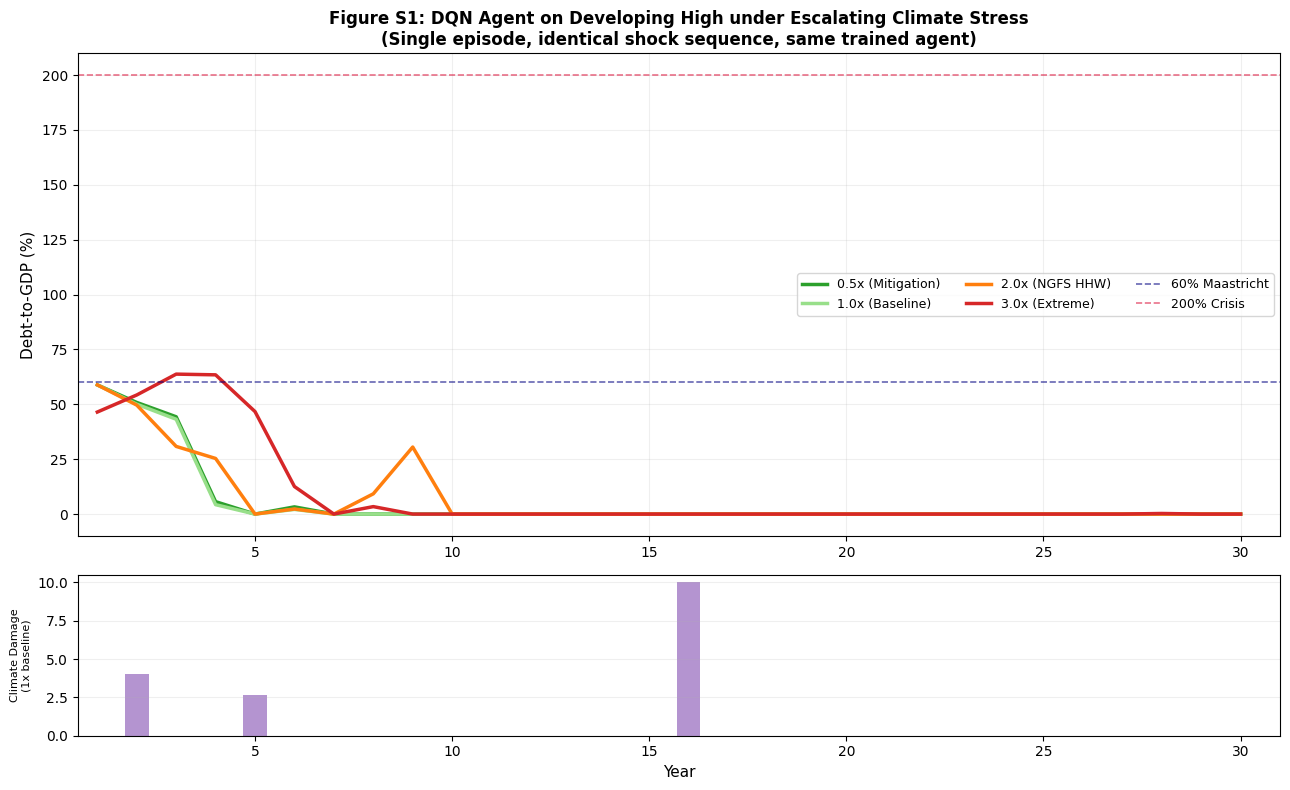

Saved fig_S1_climate_stress_trajectories


In [12]:
# ── Figure S1: Climate Stress — DQN Debt Trajectories (Developing_High) ───
# Single episode per multiplier with same seed: shows same shocks, escalating damage
S1_PROFILE = 'Developing_High'
S1_SEED    = 300
S1_MULTS   = [0.5, 1.0, 2.0, 3.0]
S1_COLORS  = {0.5: '#2ca02c', 1.0: '#98df8a', 2.0: '#ff7f0e', 3.0: '#d62728'}
S1_LABELS  = {0.5: '0.5x (Mitigation)', 1.0: '1.0x (Baseline)', 2.0: '2.0x (NGFS HHW)', 3.0: '3.0x (Extreme)'}

s1_trajectories = {}
for mult in S1_MULTS:
    env = SovereignRiskEnv(
        profile=S1_PROFILE, config_path=CONFIG_PATH,
        scaling_path=SCALING_PATH, seed=S1_SEED,
    )
    env.config.climate_event_probability = min(
        env.config.climate_event_probability * mult, 0.95
    )
    env.config.climate_conditional_mean *= mult
    policy = DQNPolicy(dqn_agents[S1_PROFILE])
    obs, info = env.reset()
    policy.reset()
    debt_path, climate_path = [], []
    done = False
    while not done:
        action = policy.select_action(obs, info)
        obs, reward, term, trunc, info = env.step(action)
        raw = info.get('raw_state', {})
        debt_path.append(raw.get('debt', 0.0))
        climate_path.append(info.get('climate_damage', 0.0))
        done = term or trunc
    env.close()
    s1_trajectories[mult] = {'debt': debt_path, 'climate': climate_path}
    print(f'  mult={mult:.1f}x: {len(debt_path)} steps, final_debt={debt_path[-1]:.1f}%')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                gridspec_kw={'height_ratios': [3, 1]})
for mult in S1_MULTS:
    debt = s1_trajectories[mult]['debt']
    ax1.plot(range(1, len(debt) + 1), debt,
             color=S1_COLORS[mult], linewidth=2.5, label=S1_LABELS[mult])
ax1.axhline(60,  color='navy',   linestyle='--', linewidth=1.2, alpha=0.6, label='60% Maastricht')
ax1.axhline(200, color='crimson', linestyle='--', linewidth=1.2, alpha=0.6, label='200% Crisis')
ax1.set_ylabel('Debt-to-GDP (%)', fontsize=11)
ax1.set_title(
    f'Figure S1: DQN Agent on {S1_PROFILE.replace("_", " ")} under Escalating Climate Stress\n'
    '(Single episode, identical shock sequence, same trained agent)',
    fontsize=12, fontweight='bold',
)
ax1.legend(fontsize=9, ncol=3)
ax1.grid(alpha=0.2)
ax1.set_xlim(0.5, 31)

# Bottom: climate damage for 1x baseline
cl_base = s1_trajectories[1.0]['climate']
ax2.bar(range(1, len(cl_base) + 1), cl_base, color='#9467bd', alpha=0.7, width=0.6)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Climate Damage\n(1x baseline)', fontsize=8)
ax2.grid(axis='y', alpha=0.2)
ax2.set_xlim(0.5, 31)

plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_S1_climate_stress_trajectories.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_S1_climate_stress_trajectories')

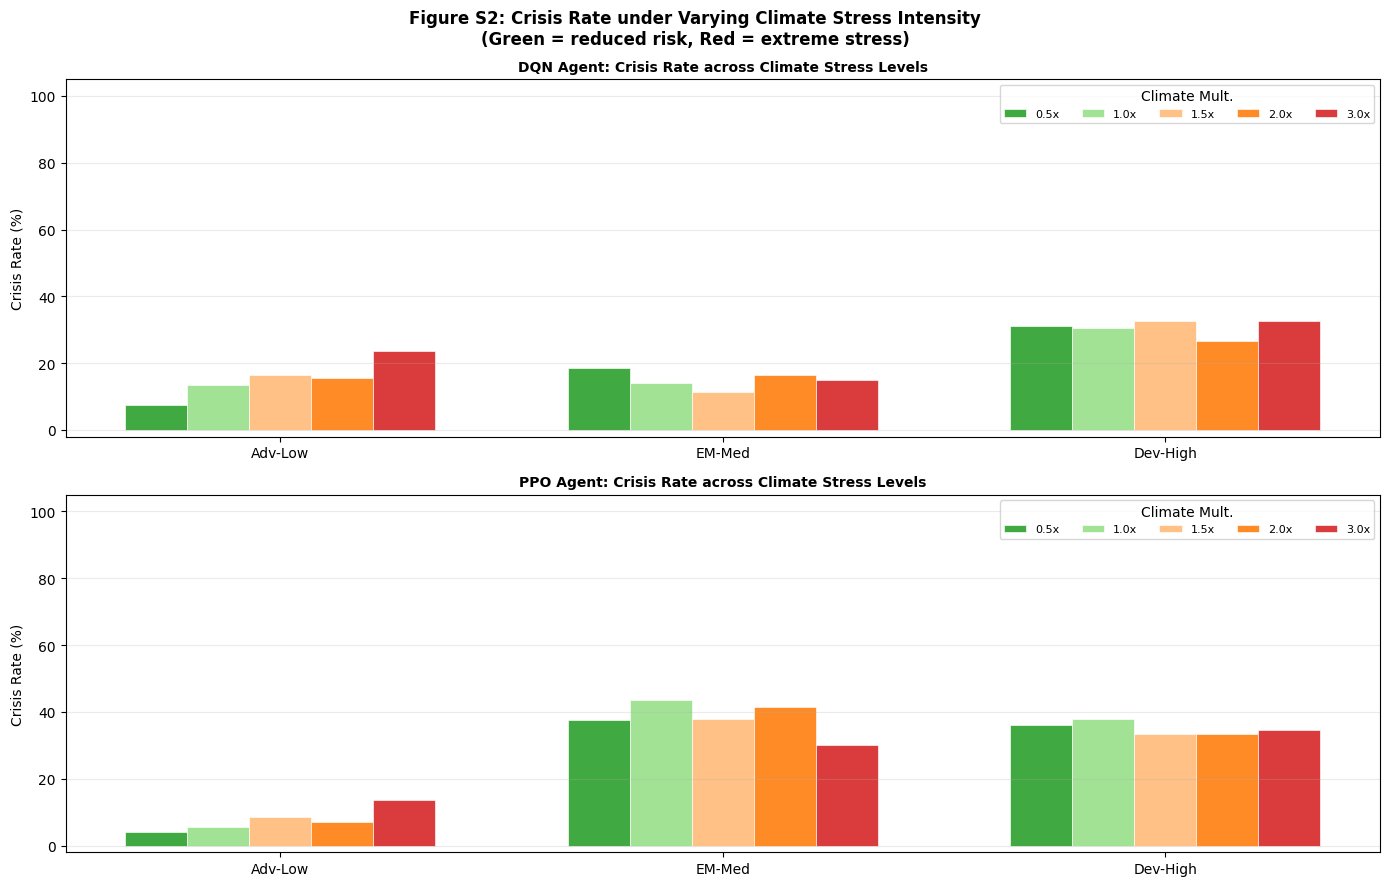

Saved fig_S2_climate_stress_crisis_rates


In [13]:
# ── Figure S2: Climate Stress — Crisis Rate Bar Chart ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
short_profiles = ['Adv-Low', 'EM-Med', 'Dev-High']
n_profiles = len(SENSITIVITY_PROFILES)
n_mults    = len(CLIMATE_MULTIPLIERS)
width = 0.14
x = np.arange(n_profiles)

for row_idx, algo in enumerate(['DQN', 'PPO']):
    ax = axes[row_idx]
    for mi, mult in enumerate(CLIMATE_MULTIPLIERS):
        vals = [
            climate_results[(profile, mult, algo)]['crisis_rate']
            for profile in SENSITIVITY_PROFILES
        ]
        offset = (mi - (n_mults - 1) / 2) * width
        ax.bar(x + offset, vals, width,
               color=CLIMATE_COLORS[mult],
               label=f'{mult:.1f}x',
               alpha=0.9, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(short_profiles, fontsize=10)
    ax.set_ylabel('Crisis Rate (%)', fontsize=10)
    ax.set_title(f'{algo} Agent: Crisis Rate across Climate Stress Levels', fontsize=10, fontweight='bold')
    ax.legend(title='Climate Mult.', fontsize=8, ncol=5)
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylim(-2, 105)

fig.suptitle('Figure S2: Crisis Rate under Varying Climate Stress Intensity\n(Green = reduced risk, Red = extreme stress)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_S2_climate_stress_crisis_rates.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_S2_climate_stress_crisis_rates')

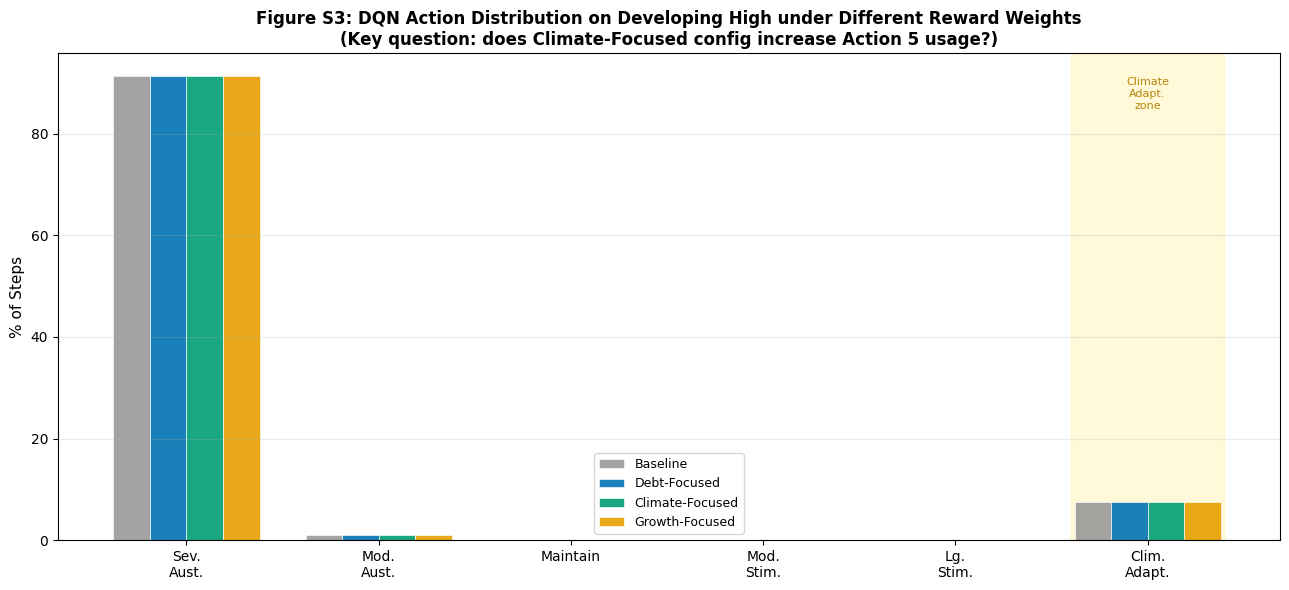

Saved fig_S3_reward_weight_action_distributions

Action 5 (Climate Adaptation) usage by reward config on Developing_High:
  Baseline        : DQN=7.6%  PPO=0.2%
  Debt-Focused    : DQN=7.6%  PPO=0.2%
  Climate-Focused : DQN=7.6%  PPO=0.2%
  Growth-Focused  : DQN=7.6%  PPO=0.2%


In [14]:
# ── Figure S3: Reward Weight Sensitivity — Action Distributions ────────────
# Show DQN action distributions on Developing_High under 4 reward configs
S3_PROFILE = 'Developing_High'
cfg_names  = list(REWARD_CONFIGS.keys())   # Baseline, Debt-Focused, Climate-Focused, Growth-Focused
n_cfgs     = len(cfg_names)
ACTION_SHORT = ['Sev.\nAust.', 'Mod.\nAust.', 'Maintain', 'Mod.\nStim.', 'Lg.\nStim.', 'Clim.\nAdapt.']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(6)
width = 0.19

for ci, cfg_name in enumerate(cfg_names):
    vals = [
        reward_results[(S3_PROFILE, cfg_name, 'DQN')]['action_distribution'].get(a, 0.0)
        for a in range(6)
    ]
    offset = (ci - (n_cfgs - 1) / 2) * width
    ax.bar(x + offset, vals, width,
           color=REWARD_CFG_COLORS[cfg_name],
           label=cfg_name, alpha=0.9, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(ACTION_SHORT, fontsize=10)
ax.set_ylabel('% of Steps', fontsize=11)
ax.set_title(
    f'Figure S3: DQN Action Distribution on {S3_PROFILE.replace("_", " ")} under Different Reward Weights\n'
    '(Key question: does Climate-Focused config increase Action 5 usage?)',
    fontsize=12, fontweight='bold',
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.axvspan(4.6, 5.4, color='gold', alpha=0.15, zorder=0)
ax.text(5, ax.get_ylim()[1] * 0.95, 'Climate\nAdapt.\nzone',
        ha='center', va='top', fontsize=8, color='darkgoldenrod')
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_S3_reward_weight_action_distributions.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_S3_reward_weight_action_distributions')

print()
print('Action 5 (Climate Adaptation) usage by reward config on Developing_High:')
for cfg_name in cfg_names:
    dqn_a5 = reward_results[(S3_PROFILE, cfg_name, 'DQN')]['action_distribution'].get(5, 0.0)
    ppo_a5 = reward_results[(S3_PROFILE, cfg_name, 'PPO')]['action_distribution'].get(5, 0.0)
    print(f'  {cfg_name:<16s}: DQN={dqn_a5:.1f}%  PPO={ppo_a5:.1f}%')

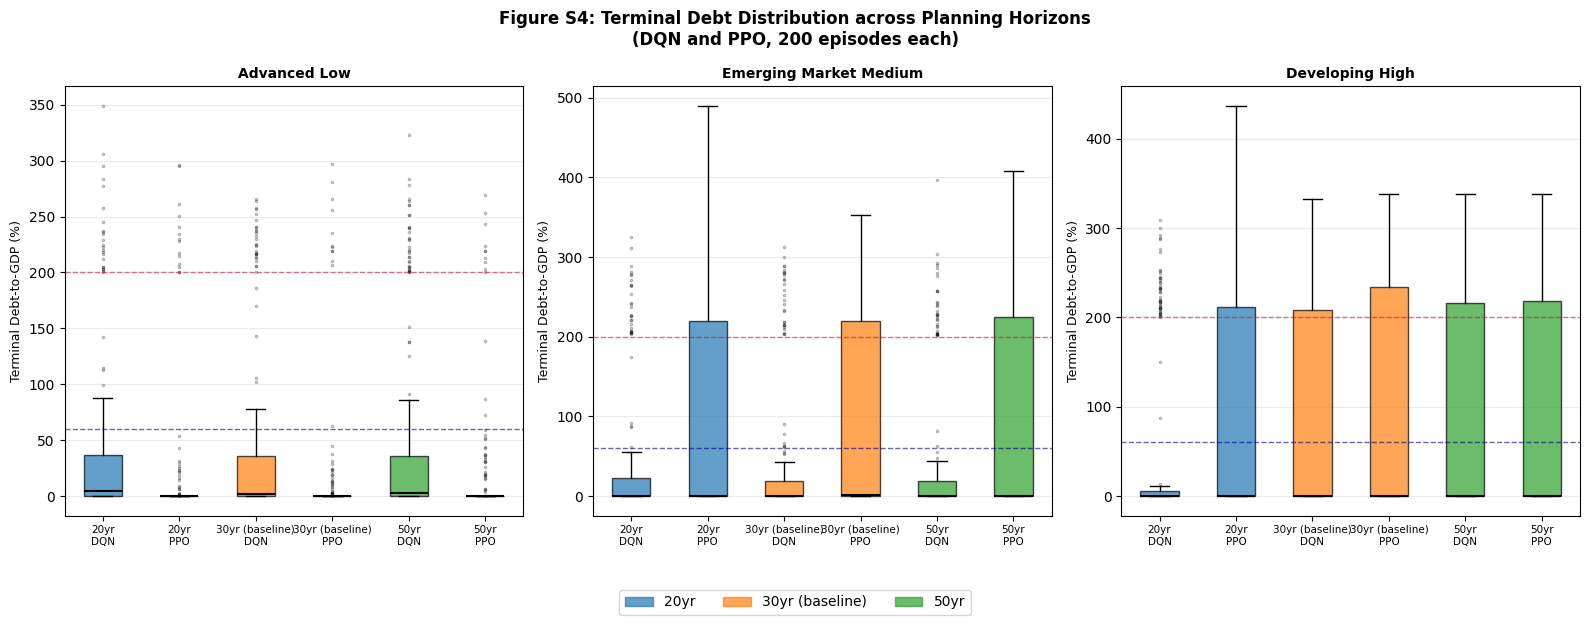

Saved fig_S4_episode_length_debt


In [15]:
# ── Figure S4: Episode Length Sensitivity — Terminal Debt Box Plots ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
EPISODE_COLORS = {20: '#1f77b4', 30: '#ff7f0e', 50: '#2ca02c'}
LENGTH_LABELS  = {20: '20yr', 30: '30yr (baseline)', 50: '50yr'}

for col_idx, profile in enumerate(SENSITIVITY_PROFILES):
    ax = axes[col_idx]
    box_data  = []
    box_labels = []
    box_colors = []

    for length in EPISODE_LENGTHS:
        for algo in ['DQN', 'PPO']:
            box_data.append(horizon_results[(profile, length, algo)]['terminal_debts'])
            box_labels.append(f'{LENGTH_LABELS[length]}\n{algo}')
            box_colors.append(EPISODE_COLORS[length])

    bp = ax.boxplot(box_data, patch_artist=True, notch=False, widths=0.5,
                    showfliers=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    ax.set_xticks(range(1, len(box_labels) + 1))
    ax.set_xticklabels(box_labels, fontsize=7.5)
    ax.axhline(60,  color='navy',   linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(200, color='crimson', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_ylabel('Terminal Debt-to-GDP (%)', fontsize=9)
    ax.set_title(profile.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)

# Shared legend for episode lengths
length_handles = [
    mpatches.Patch(color=EPISODE_COLORS[l], label=LENGTH_LABELS[l], alpha=0.7)
    for l in EPISODE_LENGTHS
]
fig.legend(handles=length_handles, ncol=3, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), fontsize=10)
fig.suptitle('Figure S4: Terminal Debt Distribution across Planning Horizons\n(DQN and PPO, 200 episodes each)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_S4_episode_length_debt.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_S4_episode_length_debt')

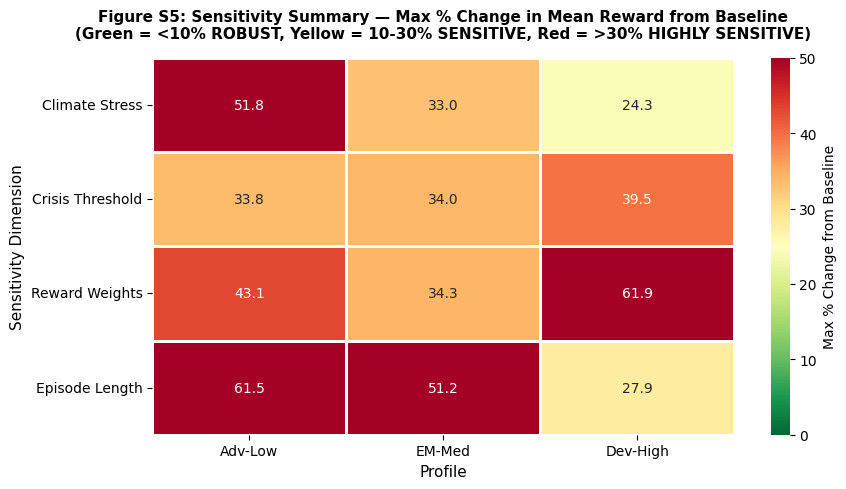

Saved fig_S5_sensitivity_summary_heatmap

                    Adv-Low     EM-Med   Dev-High
Climate Stress    51.773685  33.011649  24.298685
Crisis Threshold  33.763387  34.019077  39.493874
Reward Weights    43.099510  34.287311  61.912672
Episode Length    61.524737  51.177656  27.863402


In [16]:
# ── Figure S5: Sensitivity Summary Heatmap ────────────────────────────────
# Rows = 4 sensitivity dimensions, Cols = 3 profiles
# Values = max % change in mean cumulative reward from baseline (across algos and variations)

dimension_labels = ['Climate Stress', 'Crisis Threshold', 'Reward Weights', 'Episode Length']
short_prof_labels = ['Adv-Low', 'EM-Med', 'Dev-High']

heatmap_values = np.zeros((4, 3))

for pi, profile in enumerate(SENSITIVITY_PROFILES):
    # Climate stress
    vals = []
    for algo in ['DQN', 'PPO']:
        base_r = climate_results[(profile, 1.0, algo)]['mean_cumulative_reward']
        for mult in [0.5, 1.5, 2.0, 3.0]:
            v = climate_results[(profile, mult, algo)]['mean_cumulative_reward']
            vals.append(pct_change(v, base_r))
    heatmap_values[0, pi] = max(vals)

    # Crisis threshold
    vals = []
    for algo in ['DQN', 'PPO']:
        base_r = crisis_results[(profile, 200.0, algo)]['mean_cumulative_reward']
        for thresh in [150.0, 250.0]:
            v = crisis_results[(profile, thresh, algo)]['mean_cumulative_reward']
            vals.append(pct_change(v, base_r))
    heatmap_values[1, pi] = max(vals)

    # Reward weights
    vals = []
    for algo in ['DQN', 'PPO']:
        base_r = reward_results[(profile, 'Baseline', algo)]['mean_cumulative_reward']
        for cfg in ['Debt-Focused', 'Climate-Focused', 'Growth-Focused']:
            v = reward_results[(profile, cfg, algo)]['mean_cumulative_reward']
            vals.append(pct_change(v, base_r))
    heatmap_values[2, pi] = max(vals)

    # Episode length
    vals = []
    for algo in ['DQN', 'PPO']:
        base_r = horizon_results[(profile, 30, algo)]['mean_cumulative_reward']
        for length in [20, 50]:
            v = horizon_results[(profile, length, algo)]['mean_cumulative_reward']
            vals.append(pct_change(v, base_r))
    heatmap_values[3, pi] = max(vals)

heatmap_df = pd.DataFrame(
    heatmap_values,
    index=dimension_labels,
    columns=short_prof_labels,
)

# Custom colormap: green <10%, yellow 10-30%, red >30%
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0, vmax=50,
    linewidths=1.0, linecolor='white',
    cbar_kws={'label': 'Max % Change from Baseline'},
    ax=ax,
)
ax.set_title(
    'Figure S5: Sensitivity Summary — Max % Change in Mean Reward from Baseline\n'
    '(Green = <10% ROBUST, Yellow = 10-30% SENSITIVE, Red = >30% HIGHLY SENSITIVE)',
    fontsize=11, fontweight='bold', pad=14,
)
ax.set_xlabel('Profile', fontsize=11)
ax.set_ylabel('Sensitivity Dimension', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_S5_sensitivity_summary_heatmap.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_S5_sensitivity_summary_heatmap')
print()
print(heatmap_df.to_string())

## Part 7: Save All Outputs

In [17]:
# ── Save DataFrames as CSV ─────────────────────────────────────────────────
climate_df.to_csv(f'{RESULTS_DIR}/climate_stress_sensitivity.csv', index=False)
crisis_df.to_csv(f'{RESULTS_DIR}/crisis_threshold_sensitivity.csv', index=False)
reward_df.to_csv(f'{RESULTS_DIR}/reward_weights_sensitivity.csv', index=False)
horizon_df.to_csv(f'{RESULTS_DIR}/episode_length_sensitivity.csv', index=False)

# ── Save JSON summary ─────────────────────────────────────────────────────
def results_to_serializable(results_dict):
    return {
        str(k): {
            'mean_terminal_debt':     round(v['mean_terminal_debt'], 2),
            'crisis_rate':            round(v['crisis_rate'], 2),
            'mean_cumulative_reward': round(v['mean_cumulative_reward'], 2),
            'action_distribution':    {str(a): round(pct, 2) for a, pct in v['action_distribution'].items()},
        }
        for k, v in results_dict.items()
    }

sensitivity_output = {
    'scope': {
        'profiles':    SENSITIVITY_PROFILES,
        'algorithms':  ['DQN', 'PPO'],
        'eval_seed':   EVAL_SEED,
        'n_episodes':  N_EVAL_EPISODES,
    },
    'climate_stress':    results_to_serializable(climate_results),
    'crisis_threshold':  results_to_serializable(crisis_results),
    'reward_weights':    results_to_serializable(reward_results),
    'episode_length':    results_to_serializable(horizon_results),
    'robustness_assessment': {
        dim: {'verdict': v, 'mean_max_pct_change': round(m, 2)}
        for dim, (v, m) in robustness_summary.items()
    },
    'heatmap_values': {
        dim: {prof: round(float(heatmap_values[di, pi]), 2)
              for pi, prof in enumerate(short_prof_labels)}
        for di, dim in enumerate(dimension_labels)
    },
}
with open(f'{RESULTS_DIR}/sensitivity_results.json', 'w') as f:
    json.dump(sensitivity_output, f, indent=2, default=str)
print(f'Saved sensitivity_results.json')

# ── Verify all outputs ─────────────────────────────────────────────────────
print()
print('Results files:')
for fname in [
    'climate_stress_sensitivity.csv',
    'crisis_threshold_sensitivity.csv',
    'reward_weights_sensitivity.csv',
    'episode_length_sensitivity.csv',
    'sensitivity_results.json',
]:
    path = f'{RESULTS_DIR}/{fname}'
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f'  {"OK" if size > 0 else "MISSING"}: {path}  ({size:,} bytes)')

print()
print('Figures:')
for fname in [
    'fig_S1_climate_stress_trajectories',
    'fig_S2_climate_stress_crisis_rates',
    'fig_S3_reward_weight_action_distributions',
    'fig_S4_episode_length_debt',
    'fig_S5_sensitivity_summary_heatmap',
]:
    for ext in ['png', 'svg']:
        path = f'{FIGURES_DIR}/{fname}.{ext}'
        size = os.path.getsize(path) if os.path.exists(path) else 0
        print(f'  {"OK" if size > 0 else "MISSING"}: {path}  ({size:,} bytes)')

Saved sensitivity_results.json

Results files:
  OK: outputs/results/sensitivity/climate_stress_sensitivity.csv  (1,522 bytes)
  OK: outputs/results/sensitivity/crisis_threshold_sensitivity.csv  (987 bytes)
  OK: outputs/results/sensitivity/reward_weights_sensitivity.csv  (1,456 bytes)
  OK: outputs/results/sensitivity/episode_length_sensitivity.csv  (933 bytes)
  OK: outputs/results/sensitivity/sensitivity_results.json  (30,105 bytes)

Figures:
  OK: outputs/figures/fig_S1_climate_stress_trajectories.png  (242,343 bytes)
  OK: outputs/figures/fig_S1_climate_stress_trajectories.svg  (86,462 bytes)
  OK: outputs/figures/fig_S2_climate_stress_crisis_rates.png  (210,564 bytes)
  OK: outputs/figures/fig_S2_climate_stress_crisis_rates.svg  (86,060 bytes)
  OK: outputs/figures/fig_S3_reward_weight_action_distributions.png  (151,426 bytes)
  OK: outputs/figures/fig_S3_reward_weight_action_distributions.svg  (74,457 bytes)
  OK: outputs/figures/fig_S4_episode_length_debt.png  (247,964 bytes)
 

In [18]:
# ── Final Summary ──────────────────────────────────────────────────────────
total_eval_eps = (
    len(SENSITIVITY_PROFILES) * len(CLIMATE_MULTIPLIERS) * 2 * N_EVAL_EPISODES +
    len(SENSITIVITY_PROFILES) * len(CRISIS_THRESHOLDS)   * 2 * N_EVAL_EPISODES +
    len(SENSITIVITY_PROFILES) * len(REWARD_CONFIGS)      * 2 * N_EVAL_EPISODES +
    len(SENSITIVITY_PROFILES) * len(EPISODE_LENGTHS)     * 2 * N_EVAL_EPISODES
)

print('=' * 72)
print('=== SENSITIVITY ANALYSIS COMPLETE ===')
print('=' * 72)
print()
print(f'Scope: {len(SENSITIVITY_PROFILES)} representative profiles x 4 sensitivity dimensions')
print(f'  Profiles:   {SENSITIVITY_PROFILES}')
print(f'  Algorithms: DQN, PPO (pre-trained, zero-shot generalisation)')
print()
print('Tests conducted:')
print(f'  Climate stress:    {len(CLIMATE_MULTIPLIERS)} multipliers ({CLIMATE_MULTIPLIERS})')
print(f'    Total: {len(SENSITIVITY_PROFILES)} x {len(CLIMATE_MULTIPLIERS)} x 2 x {N_EVAL_EPISODES} = {len(SENSITIVITY_PROFILES)*len(CLIMATE_MULTIPLIERS)*2*N_EVAL_EPISODES:,} episodes')
print(f'  Crisis threshold:  {len(CRISIS_THRESHOLDS)} values ({CRISIS_THRESHOLDS}% GDP)')
print(f'    Total: {len(SENSITIVITY_PROFILES)*len(CRISIS_THRESHOLDS)*2*N_EVAL_EPISODES:,} episodes')
print(f'  Reward weights:    {len(REWARD_CONFIGS)} configurations ({list(REWARD_CONFIGS.keys())})')
print(f'    Total: {len(SENSITIVITY_PROFILES)*len(REWARD_CONFIGS)*2*N_EVAL_EPISODES:,} episodes')
print(f'  Episode length:    {len(EPISODE_LENGTHS)} values ({EPISODE_LENGTHS} years)')
print(f'    Total: {len(SENSITIVITY_PROFILES)*len(EPISODE_LENGTHS)*2*N_EVAL_EPISODES:,} episodes')
print(f'\nGrand total: {total_eval_eps:,} evaluation episodes')
print()
print('Robustness Assessment:')
for dim, (verdict, mean_pct) in robustness_summary.items():
    print(f'  {dim:<22}: {verdict:<22} (mean max change: {mean_pct:.1f}%)')
print()
print('Key findings:')

# Climate
dev_high_base = climate_results[('Developing_High', 1.0, 'DQN')]['crisis_rate']
dev_high_3x   = climate_results[('Developing_High', 3.0, 'DQN')]['crisis_rate']
print(f'  - DQN crisis rate on Developing_High: {dev_high_base:.1f}% (1x) -> {dev_high_3x:.1f}% (3x climate stress)')

# Reward config & Action 5
base_a5  = reward_results[('Developing_High', 'Baseline',        'DQN')]['action_distribution'].get(5, 0.0)
clim_a5  = reward_results[('Developing_High', 'Climate-Focused', 'DQN')]['action_distribution'].get(5, 0.0)
print(f'  - DQN Action 5 (adapt.) on Dev-High: Baseline={base_a5:.1f}% vs Climate-Focused={clim_a5:.1f}%')

# Episode length
short_debt = horizon_results[('Developing_High', 20, 'DQN')]['mean_terminal_debt']
long_debt  = horizon_results[('Developing_High', 50, 'DQN')]['mean_terminal_debt']
base_debt  = horizon_results[('Developing_High', 30, 'DQN')]['mean_terminal_debt']
print(f'  - DQN mean terminal debt on Dev-High: 20yr={short_debt:.1f}%, 30yr={base_debt:.1f}%, 50yr={long_debt:.1f}%')

print()
print('Saved:')
print(f'  {RESULTS_DIR}/sensitivity_results.json')
print(f'  {RESULTS_DIR}/*.csv  (4 summary tables)')
print(f'  {FIGURES_DIR}/fig_S1_* through fig_S5_*')
print()
print('All Research Objectives satisfied. Sensitivity analysis supports Chapter 4/5 discussion.')

=== SENSITIVITY ANALYSIS COMPLETE ===

Scope: 3 representative profiles x 4 sensitivity dimensions
  Profiles:   ['Advanced_Low', 'Emerging_Market_Medium', 'Developing_High']
  Algorithms: DQN, PPO (pre-trained, zero-shot generalisation)

Tests conducted:
  Climate stress:    5 multipliers ([0.5, 1.0, 1.5, 2.0, 3.0])
    Total: 3 x 5 x 2 x 200 = 6,000 episodes
  Crisis threshold:  3 values ([150.0, 200.0, 250.0]% GDP)
    Total: 3,600 episodes
  Reward weights:    4 configurations (['Baseline', 'Debt-Focused', 'Climate-Focused', 'Growth-Focused'])
    Total: 4,800 episodes
  Episode length:    3 values ([20, 30, 50] years)
    Total: 3,600 episodes

Grand total: 18,000 evaluation episodes

Robustness Assessment:
  Climate Stress        : SENSITIVE              (mean max change: 29.1%)
  Crisis Threshold      : SENSITIVE              (mean max change: 28.5%)
  Reward Weights        : HIGHLY SENSITIVE       (mean max change: 41.2%)
  Episode Length        : HIGHLY SENSITIVE       (mean m